In [1]:
!ls /kaggle/input/casia-20-image-tampering-detection-dataset/CASIA2

 Au  'CASIA 2 Groundtruth'   Tp


In [2]:
import os
import cv2
from tqdm import tqdm 
SRC_REAL_PATH = '/kaggle/input/casia-20-image-tampering-detection-dataset/CASIA2/Au/'
SRC_FAKE_PATH = '/kaggle/input/casia-20-image-tampering-detection-dataset/CASIA2/Tp/'

OUT_DIR = '/kaggle/working/dataset_amplified/'
OUT_REAL_PATH = os.path.join(OUT_DIR, 'real')
OUT_FAKE_PATH = os.path.join(OUT_DIR, 'fake')

# --- 2. Create Output Directories ---
os.makedirs(OUT_REAL_PATH, exist_ok=True)
os.makedirs(OUT_FAKE_PATH, exist_ok=True)

# --- 3. Define a function to process and amplify images ---
def amplify_images(src_folder, out_folder, quality_factors, file_prefix):
    """
    Reads images from a source folder, saves multiple compressed versions
    to an output folder, and reports progress.
    """
    files = os.listdir(src_folder)
    print(f"Amplifying {len(files)} images from {src_folder}...")

    # Wrap the loop with tqdm for a progress bar
    for filename in tqdm(files):
        try:
            # Construct full file path
            src_path = os.path.join(src_folder, filename)
            img = cv2.imread(src_path)
            
            # Skip if image can't be read (e.g., corrupted file)
            if img is None:
                continue

            # Save a version for each specified quality factor
            for qf in quality_factors:
                base_name = os.path.splitext(filename)[0]
                # Create a descriptive new filename
                out_filename = f"{file_prefix}_{base_name}_qf{qf}.jpg"
                out_path = os.path.join(out_folder, out_filename)
                
                # Save the image with the specified JPEG quality
                cv2.imwrite(out_path, img, [cv2.IMWRITE_JPEG_QUALITY, qf])
                
        except Exception as e:
            print(f"\nSkipping {filename} due to error: {e}")

# --- 4. Define the Amplification and Balancing Strategy ---
# For the 7,492 'real' images, create 3 versions each
real_qfs = [95, 85, 75] 

# For the 5,125 'fake' images, create 4 versions each to balance the dataset
fake_qfs = [90, 80, 70, 60]

# --- 5. Run the Amplification ---
print("Starting data amplification process...")

# Amplify authentic images
amplify_images(SRC_REAL_PATH, OUT_REAL_PATH, real_qfs, 'real')

# Amplify tampered images
amplify_images(SRC_FAKE_PATH, OUT_FAKE_PATH, fake_qfs, 'fake')

print("\nData amplification complete!")
print(f"New dataset is ready in: {OUT_DIR}")

Starting data amplification process...
Amplifying 7492 images from /kaggle/input/casia-20-image-tampering-detection-dataset/CASIA2/Au/...


100%|██████████| 7492/7492 [01:46<00:00, 70.65it/s]


Amplifying 5125 images from /kaggle/input/casia-20-image-tampering-detection-dataset/CASIA2/Tp/...


100%|██████████| 5125/5125 [02:18<00:00, 37.02it/s]


Data amplification complete!
New dataset is ready in: /kaggle/working/dataset_amplified/


In [3]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# --- 1. Feature Extractor: Extracts DCT coefficients from image blocks ---
def extract_dct_coefficients(image_path, block_size=8):
    """
    Loads an image, gets the luminance channel, and extracts DCT coefficients
    for each 8x8 block.
    """
    try:
        img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
        # We only need the luminance channel (Y) for compression artifacts
        if len(img.shape) > 2:
            img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
            y_channel = img_ycrcb[:, :, 0]
        else:
            y_channel = img
            
        h, w = y_channel.shape
        y_channel = y_channel[:h - h % block_size, :w - w % block_size]

        dct_blocks = []
        for i in range(0, y_channel.shape[0], block_size):
            for j in range(0, y_channel.shape[1], block_size):
                block = y_channel[i:i+block_size, j:j+block_size]
                block_float = np.float32(block)
                dct_block = cv2.dct(block_float)
                dct_blocks.append(dct_block.flatten())

        return np.array(dct_blocks)
    except Exception as e:
        return None

# --- 2. Data Generator: Feeds data to the model in batches ---
def data_generator(real_path, fake_path, batch_size=256):
    """
    A generator that yields batches of DCT blocks and their labels (0=real, 1=fake).
    """
    real_files = [os.path.join(real_path, f) for f in os.listdir(real_path)]
    fake_files = [os.path.join(fake_path, f) for f in os.listdir(fake_path)]
    all_files = real_files + fake_files
    np.random.shuffle(all_files)

    while True: # Loop forever to continuously generate data
        batch_x, batch_y = [], []
        for file_path in all_files:
            dct_data = extract_dct_coefficients(file_path)
            if dct_data is not None:
                label = 1 if fake_path in file_path else 0
                for block in dct_data:
                    batch_x.append(block)
                    batch_y.append(label)
                    if len(batch_x) == batch_size:
                        # Reshape for RNN input: (batch_size, timesteps, features)
                        x = np.array(batch_x).reshape(batch_size, 64, 1)
                        y = np.array(batch_y)
                        yield x, y
                        batch_x, batch_y = [], []

# --- 3. Model Definition ---
model = Sequential([
    Input(shape=(64, 1)), # Input is a sequence of 64 coefficients
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Final output: 0 to 1 probability
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

# --- 4. Training Setup ---
TRAIN_REAL_PATH = '/kaggle/working/dataset_amplified/real/'
TRAIN_FAKE_PATH = '/kaggle/working/dataset_amplified/fake/'
BATCH_SIZE = 512 # A larger batch size is often better on GPUs

# Estimate total training blocks to calculate steps per epoch
num_real_images = len(os.listdir(TRAIN_REAL_PATH))
num_fake_images = len(os.listdir(TRAIN_FAKE_PATH))
# Estimate based on a sample image size (e.g., 800x600 -> ~7500 blocks)
# This doesn't need to be exact, but helps define an epoch's length.
total_blocks_approx = (num_real_images + num_fake_images) * ( (800*600)/(8*8) ) / 5
steps_per_epoch = int(total_blocks_approx // BATCH_SIZE)

train_gen = data_generator(TRAIN_REAL_PATH, TRAIN_FAKE_PATH, batch_size=BATCH_SIZE)

# --- 5. Start Training ---
print(f"Starting training with approx. {steps_per_epoch} steps per epoch...")
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=5 # Start with 5 epochs. You can increase this later if needed.
)

# --- 6. Save the Final Model ---
model.save('/kaggle/working/image_forensics_rnn.h5')
print("\nTraining complete! Model saved to /kaggle/working/image_forensics_rnn.h5")

2025-10-23 12:37:29.386629: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761223049.563957      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761223049.626549      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1761223062.805137      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

Starting training with approx. 125874 steps per epoch...
Epoch 1/5


I0000 00:00:1761223068.163571      60 cuda_dnn.cc:529] Loaded cuDNN version 90300


125874/125874 ━━━━━━━━━━━━━━━━━━━━ 2463s 20ms/step - accuracy: 0.5412 - loss: 0.6926
Epoch 2/5
125874/125874 ━━━━━━━━━━━━━━━━━━━━ 2475s 20ms/step - accuracy: 0.5517 - loss: 0.6887
Epoch 3/5
125874/125874 ━━━━━━━━━━━━━━━━━━━━ 2480s 20ms/step - accuracy: 0.5486 - loss: 0.6889
Epoch 4/5
125874/125874 ━━━━━━━━━━━━━━━━━━━━ 2453s 19ms/step - accuracy: 0.5450 - loss: 0.6898
Epoch 5/5
125874/125874 ━━━━━━━━━━━━━━━━━━━━ 2454s 19ms/step - accuracy: 0.5534 - loss: 0.6881

Training complete! Model saved to /kaggle/working/image_forensics_rnn.h5


In [4]:
REAL_PATH = '/kaggle/working/dataset_amplified/real/'
FAKE_PATH = '/kaggle/working/dataset_amplified/fake/'

# --- 2. Get All File Paths ---
real_files = [os.path.join(REAL_PATH, f) for f in os.listdir(REAL_PATH)]
fake_files = [os.path.join(FAKE_PATH, f) for f in os.listdir(FAKE_PATH)]

# --- 3. Shuffle and Split for Validation (80% train, 20% test) ---
np.random.shuffle(real_files)
np.random.shuffle(fake_files)

split_real = int(len(real_files) * 0.8)
split_fake = int(len(fake_files) * 0.8)

# We already used the training files, so we only need the test files
val_real_files = real_files[split_real:]
val_fake_files = fake_files[split_fake:]

val_files = val_real_files + val_fake_files
val_labels = [0] * len(val_real_files) + [1] * len(val_fake_files)

print(f"Validation set created with:")
print(f"  {len(val_real_files)} real images")
print(f"  {len(val_fake_files)} fake images")

Validation set created with:
  4495 real images
  4099 fake images


Model loaded successfully.
Running evaluation on validation set...


100%|██████████| 8594/8594 [53:30<00:00,  2.68it/s]


Evaluation complete.

--- Classification Report (The 'Real' Score) ---


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                precision    recall  f1-score   support

REAL (Class 0)       0.00      0.00      0.00   8740969
FAKE (Class 1)       0.55      1.00      0.71  10864623

      accuracy                           0.55  19605592
     macro avg       0.28      0.50      0.36  19605592
  weighted avg       0.31      0.55      0.40  19605592


--- Confusion Matrix ---


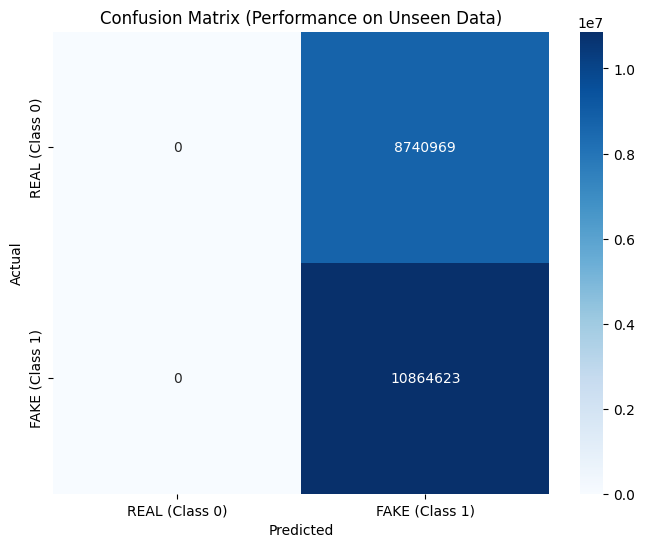

In [5]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def extract_dct_coefficients(image_path, block_size=8):
    try:
        img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
        if len(img.shape) > 2:
            img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
            y_channel = img_ycrcb[:, :, 0]
        else:
            y_channel = img
        h, w = y_channel.shape
        y_channel = y_channel[:h - h % block_size, :w - w % block_size]
        dct_blocks = []
        for i in range(0, y_channel.shape[0], block_size):
            for j in range(0, y_channel.shape[1], block_size):
                block = y_channel[i:i+block_size, j:j+block_size]
                block_float = np.float32(block)
                dct_block = cv2.dct(block_float)
                dct_blocks.append(dct_block.flatten())
        return np.array(dct_blocks)
    except Exception as e:
        return None

# --- 2. Load Your Trained Model ---
model = tf.keras.models.load_model('/kaggle/working/image_forensics_rnn.h5')
print("Model loaded successfully.")

# --- 3. Evaluate on the Validation Set ---
all_predictions = []
all_true_labels = []

print("Running evaluation on validation set...")
# Loop over each validation file
for file_path, label in tqdm(zip(val_files, val_labels), total=len(val_files)):
    dct_data = extract_dct_coefficients(file_path)
    
    if dct_data is not None and len(dct_data) > 0:
        # Reshape for RNN input
        dct_data_reshaped = dct_data.reshape(len(dct_data), 64, 1)
        
        # Get predictions (probabilities)
        predictions = model.predict(dct_data_reshaped, verbose=0)
        
        # Convert probabilities to binary classes (0 or 1)
        predicted_classes = (predictions > 0.5).astype(int)
        
        # Store predictions and labels for all blocks
        all_predictions.extend(predicted_classes.flatten())
        all_true_labels.extend([label] * len(predicted_classes))

print("Evaluation complete.")

# --- 4. Display the Results ---
print("\n--- Classification Report (The 'Real' Score) ---")
# '0' is Real, '1' is Fake
target_names = ['REAL (Class 0)', 'FAKE (Class 1)']
print(classification_report(all_true_labels, all_predictions, target_names=target_names))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(all_true_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Performance on Unseen Data)')
plt.show()

Using 8594 files for validation...
Model loaded successfully.
Running evaluation... (This will take a few minutes)


100%|██████████| 8594/8594 [54:06<00:00,  2.65it/s]


Evaluation complete. Generating reports for different thresholds...

   REPORT FOR THRESHOLD = 0.5


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                precision    recall  f1-score   support

REAL (Class 0)       0.00      0.00      0.00   8740969
FAKE (Class 1)       0.55      1.00      0.71  10864623

      accuracy                           0.55  19605592
     macro avg       0.28      0.50      0.36  19605592
  weighted avg       0.31      0.55      0.40  19605592



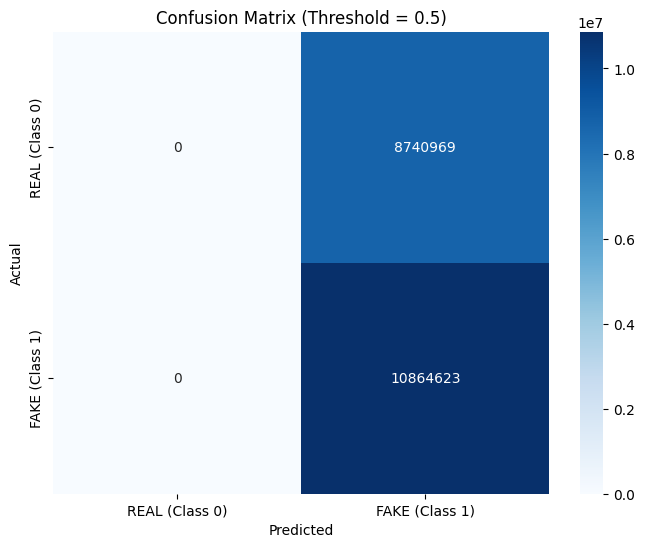


   REPORT FOR THRESHOLD = 0.75


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                precision    recall  f1-score   support

REAL (Class 0)       0.45      1.00      0.62   8740969
FAKE (Class 1)       0.00      0.00      0.00  10864623

      accuracy                           0.45  19605592
     macro avg       0.22      0.50      0.31  19605592
  weighted avg       0.20      0.45      0.27  19605592



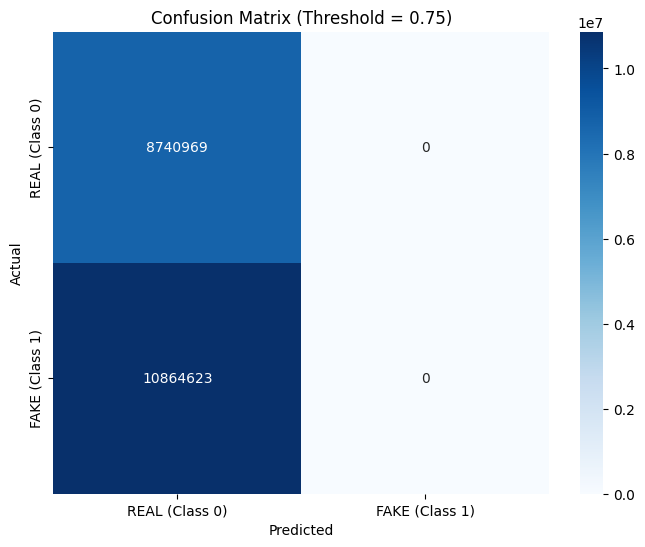


   REPORT FOR THRESHOLD = 0.85


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                precision    recall  f1-score   support

REAL (Class 0)       0.45      1.00      0.62   8740969
FAKE (Class 1)       0.00      0.00      0.00  10864623

      accuracy                           0.45  19605592
     macro avg       0.22      0.50      0.31  19605592
  weighted avg       0.20      0.45      0.27  19605592



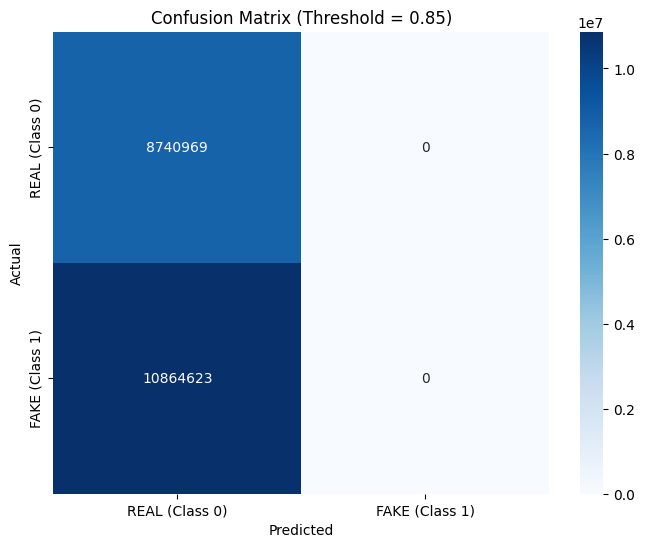


   REPORT FOR THRESHOLD = 0.95


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                precision    recall  f1-score   support

REAL (Class 0)       0.45      1.00      0.62   8740969
FAKE (Class 1)       0.00      0.00      0.00  10864623

      accuracy                           0.45  19605592
     macro avg       0.22      0.50      0.31  19605592
  weighted avg       0.20      0.45      0.27  19605592



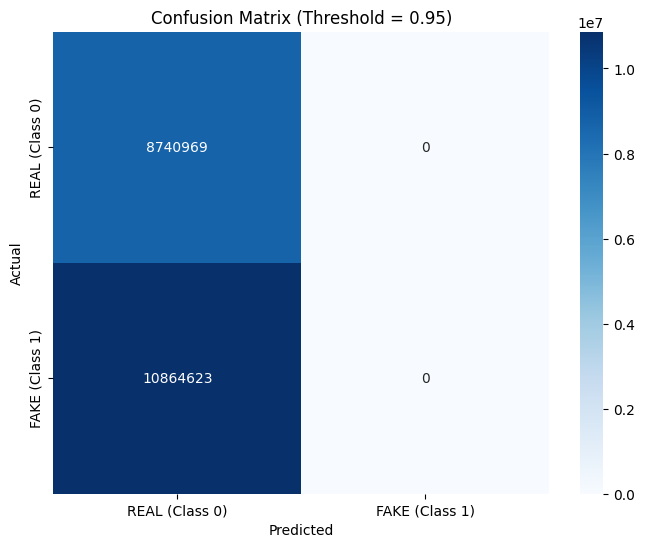

In [6]:
def extract_dct_coefficients(image_path, block_size=8):
    try:
        img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
        if len(img.shape) > 2:
            img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
            y_channel = img_ycrcb[:, :, 0]
        else:
            y_channel = img
        h, w = y_channel.shape
        y_channel = y_channel[:h - h % block_size, :w - w % block_size]
        dct_blocks = []
        for i in range(0, y_channel.shape[0], block_size):
            for j in range(0, y_channel.shape[1], block_size):
                block = y_channel[i:i+block_size, j:j+block_size]
                block_float = np.float32(block)
                dct_block = cv2.dct(block_float)
                dct_blocks.append(dct_block.flatten())
        return np.array(dct_blocks)
    except Exception as e:
        return None

# --- 2. Load Validation Files (from the previous step's variables) ---
# This assumes 'val_files' and 'val_labels' are still in your notebook's memory
print(f"Using {len(val_files)} files for validation...")

# --- 3. Load Your Trained Model ---
model = tf.keras.models.load_model('/kaggle/working/image_forensics_rnn.h5')
print("Model loaded successfully.")

# --- 4. Get Raw Probabilities (We only need to do this once) ---
all_probabilities = []
all_true_labels = []

print("Running evaluation... (This will take a few minutes)")
for file_path, label in tqdm(zip(val_files, val_labels), total=len(val_files)):
    dct_data = extract_dct_coefficients(file_path)
    
    if dct_data is not None and len(dct_data) > 0:
        dct_data_reshaped = dct_data.reshape(len(dct_data), 64, 1)
        
        # Get the raw probabilities (not the 0/1 classes)
        predictions = model.predict(dct_data_reshaped, verbose=0)
        
        all_probabilities.extend(predictions.flatten())
        all_true_labels.extend([label] * len(predictions))

print("Evaluation complete. Generating reports for different thresholds...")

# --- 5. Test Different Thresholds ---
thresholds = [0.5, 0.75, 0.85, 0.95]
target_names = ['REAL (Class 0)', 'FAKE (Class 1)']

for thresh in thresholds:
    print(f"\n========================================")
    print(f"   REPORT FOR THRESHOLD = {thresh}")
    print(f"========================================")
    
    # Apply the new threshold
    predicted_classes = (np.array(all_probabilities) > thresh).astype(int)
    
    print(classification_report(all_true_labels, predicted_classes, target_names=target_names))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(all_true_labels, predicted_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix (Threshold = {thresh})')
    plt.show()